## Plot results of human embryo reference tool

In [1]:
library(ggplot2)
library(dplyr)
library(reshape2)
library(stringr)
#library(ggpubr)
#library(ComplexHeatmap)
library(patchwork)
#library(Hmisc)
library(gghighlight)
#library(Seurat)

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘reshape2’ was built under R version 4.5.2”
Warning message:
“package ‘stringr’ was built under R version 4.5.2”


In [2]:
# define const for visualization
FONT.SIZE <- 7
LABEL.FONT.SIZE <- 7
w <- 2 
h <- 2.5
LINE.W <- 0.3 

settheme <- theme_minimal() + 
  theme(
    text = element_text(family = "sans"), 
    panel.background = element_blank(),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(),
    plot.background = element_blank(),
    
    axis.ticks = element_line(colour = "black", linewidth = LINE.W),
    axis.ticks.length = unit(0.1, "cm"), 
    axis.line = element_line(linewidth = LINE.W, colour = "black"),
    axis.title = element_text(size = FONT.SIZE),
    axis.text = element_text(colour = "black", size = FONT.SIZE),
    strip.text = element_text(size = FONT.SIZE), 
    strip.text.y.left = element_text(angle = 0, hjust = 1, size = FONT.SIZE),
    legend.position = "right",
    legend.title = element_text(size = FONT.SIZE), 
    legend.text = element_text(size = FONT.SIZE),
    legend.key.size = unit(0.3, "cm"),
    axis.text.x = element_text(colour = "black", angle = 0, size = LABEL.FONT.SIZE),
    title = element_text(size = FONT.SIZE) 
)


In [3]:
dataset_col = 
c("petropoulos_2016" = "#2195BC","meistermann_2021" = "#A2B867" , "yanagida_2021" = "#EAAA27", "xiang_2020"= "#8E55A4")

col = 
c("#2195BC","#A2B867","#EAAA27", "#D74D14", "#8E55A4", "#831B53")

col_aneu = 
c("euploid"= "white","monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0", "aneuploid" = "#676767")

In [20]:
celltype_col =c(
#'Zygote'= '#FCD888',
'Epiblast' = '#E8973E',
 #'Prelineage'='#FBD8EC',
'Amnion'='#F17A48',
'Morula'='#D74426',
'Early_EPI' ='#AB4642',
'Late_EPI'= "#AE3B36",
'ICM' ='#FBD8EC',
'ECTO' ='#FF80A9',
'EPI.PrE.INT'='#E1529D',
'AdvMes' ='#AB4979',
'Mesoderm' ='#E1529D',
'ExE_Mes' ='#D82679',
#'PriS' ='#A777CD',
'YSE'='#690FA0',
'Prelineage'= '#AC39FF',
'Hypoblast'='#3F8F91',
 'early TE' ='#CBEDB3',
#'TE'= '#B3D51C',
 'TE'= '#4B5AA3',
 'late TE' ='#49B91B',
 'polarTE'= '#A79E33',
'CTB' ='#418A7D',
 'STB' ='#508E36',
 'EVT'='#849D2C',
'DE'= '#00AAD6',
'nb_failed'='#BBBBBB',
#'Ambiguous' ='#676767',
   'Unspecified' ='#676767' ,
     'Trophoblast'= '#4B5AA3',
         "off-target(post-implantation)"= '#AB4979'
)

color_celltype2 = c(
    "naive EPI" =     "#F8B949",  # warm yellow
    "blastoid EPI" = "#E8973E",  # orange
    "TE" =        "#4B5AA3",  # blue
    "unspecified" =        "#676767")



## Load datasets

In [5]:
predict_out = readRDS("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/6_EEPT/predicted_EEPT.rds")

In [6]:
meta = read.csv('/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/3_scanpy_integration/meta_integrated_sub_fine.csv')

## Output directory

In [7]:
out_dir = "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/6_EEPT"
dir.create(out_dir,recursive = TRUE)



Warning message in dir.create(out_dir, recursive = TRUE):
“'/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/6_EEPT' already exists”


### reformat

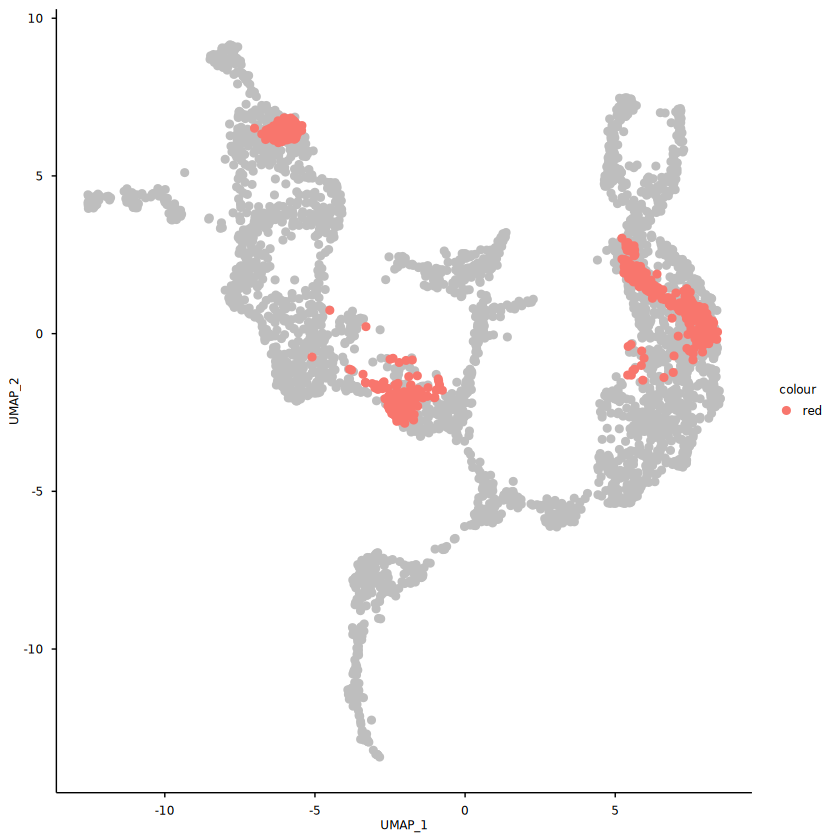

In [8]:
ggplot()+
geom_point(predict_out$umap %>% filter(pj!="query"),mapping=aes(x=UMAP_1,y=UMAP_2),color="grey")+
geom_point(predict_out$umap %>% filter(pj=="query"),mapping=aes(x=UMAP_1,y=UMAP_2,color="red"))+settheme

In [9]:
head(predict_out$umap)

,cell,UMAP_2,UMAP_1,devTime,EML,pj
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,ref_Yan_SRR491011,-5.245816,5.502827,E6,TE,ref_Yan2013
2,ref_Yan_SRR491012,-4.149948,6.909593,E6,TE,ref_Yan2013
3,ref_Yan_SRR491013,-5.031758,5.620319,E6,TE,ref_Yan2013
4,ref_Yan_SRR491014,-5.090609,5.066274,E6,TE,ref_Yan2013
5,ref_Yan_SRR491015,-5.384610,5.323843,E6,TE,ref_Yan2013
6,ref_Yan_SRR491016,-5.129345,5.480496,E6,TE,ref_Yan2013


In [10]:
head(predict_out$full.anno)

query_cell,pred_EML,sub_pred_EML,stage,prediction_score_max,pred_psdt
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,Ambiguous,Ambiguous,uncertained,0.04203338,NA
AAACCTGCAATCACAC-1_Embryo-Imp15265938,Epiblast,Early_EPI,Early,0.99958845,12.73605
AAACCTGCAGCTGCTG-1_Embryo-Imp15265938,Epiblast,Early_EPI,Early,0.99971173,12.65406
AAACCTGCAGTGACAG-1_Embryo-Imp15265938,Epiblast,Early_EPI,Early,0.99974272,12.73026
AAACCTGCATGTTGAC-1_Embryo-Imp15265938,Epiblast,Early_EPI,Early,0.99976590,12.70249
AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,Ambiguous,Ambiguous,uncertained,0.29300048,NA


In [11]:
predict_out$full.anno = predict_out$full.anno %>% 
  rename(
    cell = query_cell
    )

In [12]:
df = merge(predict_out$umap,predict_out$full.anno,by=c("cell"), all.x=TRUE)

In [13]:
head(df)

,cell,UMAP_2,UMAP_1,devTime,EML,pj,pred_EML,sub_pred_EML,stage,prediction_score_max,pred_psdt
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,AAACCTGCACACCGAC-1_Embryo-Imp15265941,-2.014735,-2.367151,None,query,query,Epiblast,Early_EPI,Early,0.99943074,12.72451
2,AAACCTGCAGACGCAA-1_Embryo-Imp15265941,6.680249,-5.993375,None,query,query,Ambiguous,Ambiguous,uncertained,0.03907552,NA
3,AAACCTGGTTGGAGGT-1_Embryo-Imp15265943,6.562323,-5.801401,None,query,query,Ambiguous,Ambiguous,uncertained,0.08345160,NA
4,AAACCTGTCCCACTTG-1_Embryo-Imp15265942,6.564585,-5.730069,None,query,query,AdvMes,AdvMes,Late,0.92318722,NA
5,AAACGGGAGCGACGTA-1_Embryo-Imp15265946,6.563414,-5.890168,None,query,query,Ambiguous,Ambiguous,uncertained,0.06506520,NA
6,AAACGGGCAAGCCTAT-1_Embryo-Imp15265942,6.321294,-5.595123,None,query,query,Ambiguous,Ambiguous,uncertained,0.03442405,NA


In [14]:
head(meta)
meta$cell = meta$cell.ID_

,X,dataset,cell.ID_,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,⋯,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,0,Embryo-Imp15265938,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,⋯,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,3,Embryo-Imp15265938,AAACCTGCAATCACAC-1_Embryo-Imp15265938,0.19064748,False,0.19851577,0.5055552,1,0.8326981,8112,⋯,8112,0.2379417,0,0,2,4,naive EPI,1,EPI_1,EPI
3,5,Embryo-Imp15265938,AAACCTGCAGCTGCTG-1_Embryo-Imp15265938,0.22540984,False,0.22540984,0.7677861,1,0.8326981,8801,⋯,8801,0.2474431,0,0,3,1,naive EPI,1,EPI_1,EPI
4,6,Embryo-Imp15265938,AAACCTGCAGTGACAG-1_Embryo-Imp15265938,0.33522727,False,0.21584158,0.6744908,1,0.8326981,7949,⋯,7949,0.3294210,9,0,3,1,naive EPI,1,EPI_1,EPI
5,8,Embryo-Imp15265938,AAACCTGCATGTTGAC-1_Embryo-Imp15265938,0.20689655,False,0.20689655,0.5872721,1,0.8326981,7336,⋯,7336,0.2769359,0,0,2,4,naive EPI,1,EPI_1,EPI
6,9,Embryo-Imp15265938,AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,0.09309967,False,0.08256881,-0.6249869,1,0.9147751,7621,⋯,7621,0.3519634,7,7,8,9,unspecified,7,unspecified_2,unspecified


In [15]:
df_umap = merge(df,meta,by=c("cell"), all.x=TRUE)

In [16]:
write.csv(df_umap, sprintf("%s/EEPT_df.csv",out_dir))

In [17]:
sprintf("%s/EEPT_df.csv",out_dir)

[1] "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/6_EEPT/EEPT_df.csv"

In [18]:
head(df_umap)

,cell,UMAP_2,UMAP_1,devTime,EML,pj,pred_EML,sub_pred_EML,stage,prediction_score_max,⋯,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,AAACCTGCACACCGAC-1_Embryo-Imp15265941,-2.014735,-2.367151,None,query,query,Epiblast,Early_EPI,Early,0.99943074,⋯,7881,0.2843069,0,0,3,1,blastoid EPI,8,EPI_2,EPI
2,AAACCTGCAGACGCAA-1_Embryo-Imp15265941,6.680249,-5.993375,None,query,query,Ambiguous,Ambiguous,uncertained,0.03907552,⋯,8685,0.4141723,12,12,13,13,unspecified,9,unspecified_1,unspecified
3,AAACCTGGTTGGAGGT-1_Embryo-Imp15265943,6.562323,-5.801401,None,query,query,Ambiguous,Ambiguous,uncertained,0.08345160,⋯,8350,0.3019639,5,9,7,14,unspecified,7,unspecified_1,unspecified
4,AAACCTGTCCCACTTG-1_Embryo-Imp15265942,6.564585,-5.730069,None,query,query,AdvMes,AdvMes,Late,0.92318722,⋯,6611,0.3130101,8,2,1,2,unspecified,0,unspecified_1,unspecified
5,AAACGGGAGCGACGTA-1_Embryo-Imp15265946,6.563414,-5.890168,None,query,query,Ambiguous,Ambiguous,uncertained,0.06506520,⋯,8178,0.3172071,4,4,4,0,unspecified,2,unspecified_1,unspecified
6,AAACGGGCAAGCCTAT-1_Embryo-Imp15265942,6.321294,-5.595123,None,query,query,Ambiguous,Ambiguous,uncertained,0.03442405,⋯,5366,0.3244019,8,8,9,8,unspecified,0,unspecified_1,unspecified


## plot

In [41]:
celltype_col =c(
#'Zygote'= '#FCD888',
'Epiblast' = '#E8973E',
 #'Prelineage'='#FBD8EC',
'Amnion'='#F17A48',
'Morula'='#D74426',
'Early_EPI' ='#AB4642',
'Late_EPI'= "#AE3B36",
#'ICM' ='#FBD8EC',
'ECTO' ='#FF80A9',
#'EPI.PrE.INT'='#E1529D',
'AdvMes' ='#AB4979',
'Mesoderm' ='#E1529D',
'ExE_Mes' ='#D82679',
#'PriS' ='#A777CD',
#'YSE'='#690FA0',
#'Prelineage'= '#AC39FF',
'Hypoblast'='#FBD8EC',
 'early TE' ='#CBEDB3',
#'TE'= '#B3D51C',
 'TE'= '#4B5AA3',
 'late TE' ='#49B91B',
 'polarTE'= '#A79E33',
'CTB' ='#418A7D',
 'STB' ='#508E36',
 'EVT'='#849D2C',
#'DE'= '#00AAD6',
'nb_failed'='#BBBBBB',
'Ambiguous' ='#676767',
   'Unspecified' ='#676767' ,
     'Trophoblast'= '#4B5AA3',
         "off-target(post-implantation)"= '#AB4979'
)

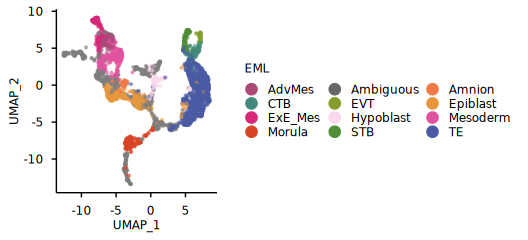

In [42]:
title = "UMAP_EML"

w <- 4.4
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = EML)) + 
    geom_point(size = 0.1, alpha = 0.5)+
    settheme+
  theme(
    legend.position = "right")+
  guides(color = guide_legend(
    ncol = 3, byrow = TRUE,
    override.aes = list(size = 2.5, alpha = 1)
  )) +
  scale_color_manual(values=celltype_col)

ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

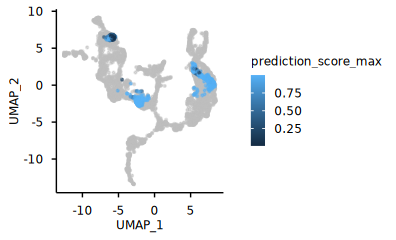

In [20]:
title = "UMAP_prediction_score_max"

w <- 3.3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = prediction_score_max)) + 
    geom_point(size = 0.1, alpha = 0.5)+
    gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
    settheme

ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

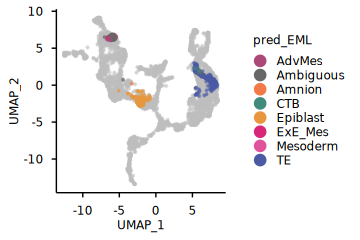

In [21]:
title = "UMAP_pred_EML"

w <- 3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = pred_EML)) + 
    geom_point(size = 0.1, alpha = 0.5)+
    gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
    settheme+
  guides(color = guide_legend(
    ncol = 1, byrow = TRUE,
    override.aes = list(size = 2.5, alpha = 1)
  ))+
  scale_color_manual(values=celltype_col)

ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

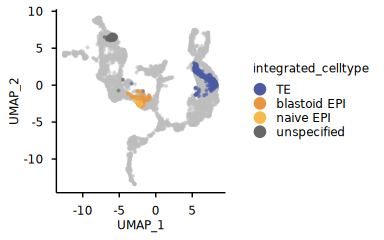

In [31]:
title = "UMAP_annotated"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = integrated_celltype)) + 
    geom_point(size = 0.1, alpha = 0.5)+
    gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
    settheme+
  guides(color = guide_legend(
    ncol = 1, byrow = TRUE,
    override.aes = list(size = 2.5, alpha = 1)
  ))+
  scale_color_manual(values=color_celltype2)

ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

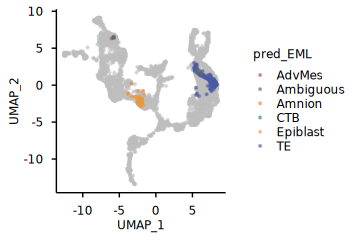

In [22]:
title = "UMAP_T3_ctr"

w <- 3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = pred_EML)) + 
    geom_point(size = 0.1, alpha = 0.5)+
    gghighlight(sample == 'T3_control', use_direct_label = FALSE, use_group_by = FALSE)+
    settheme+
  scale_color_manual(values=celltype_col)

ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

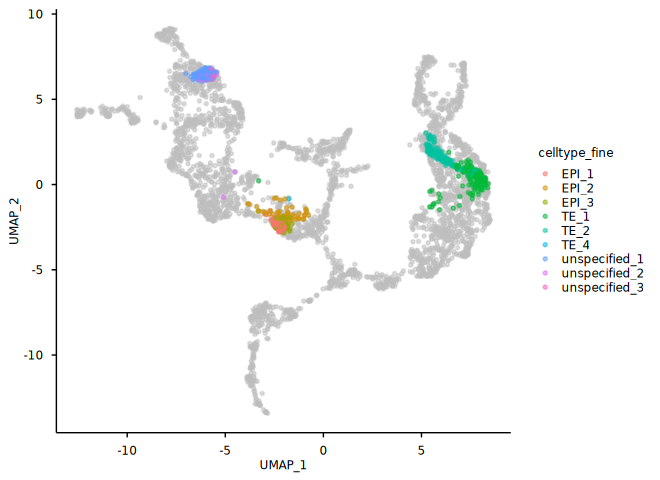

In [23]:
title = "UMAP_fine"

w <- 5.5
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = celltype_fine)) + 
    geom_point(size = 0.5, alpha = 0.5)+
    gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
    settheme

ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

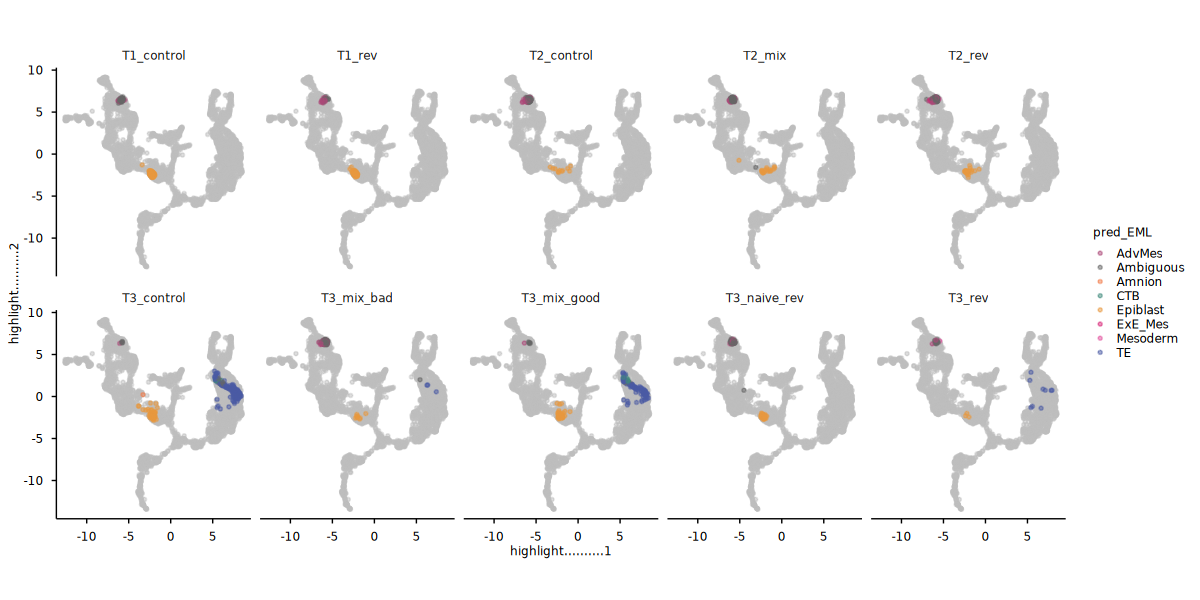

In [24]:
title = "UMAP_predictied_EML"

w <- 10
h <- 5
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = pred_EML)) + 
    geom_point(size = 0.5, alpha = 0.5)+
    settheme+
    theme(axis.text.x = element_text(angle = 0))+
  coord_fixed(ratio = 1) +
  gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
 facet_wrap(~ sample, nrow =2)+
  scale_color_manual(values=celltype_col)


ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

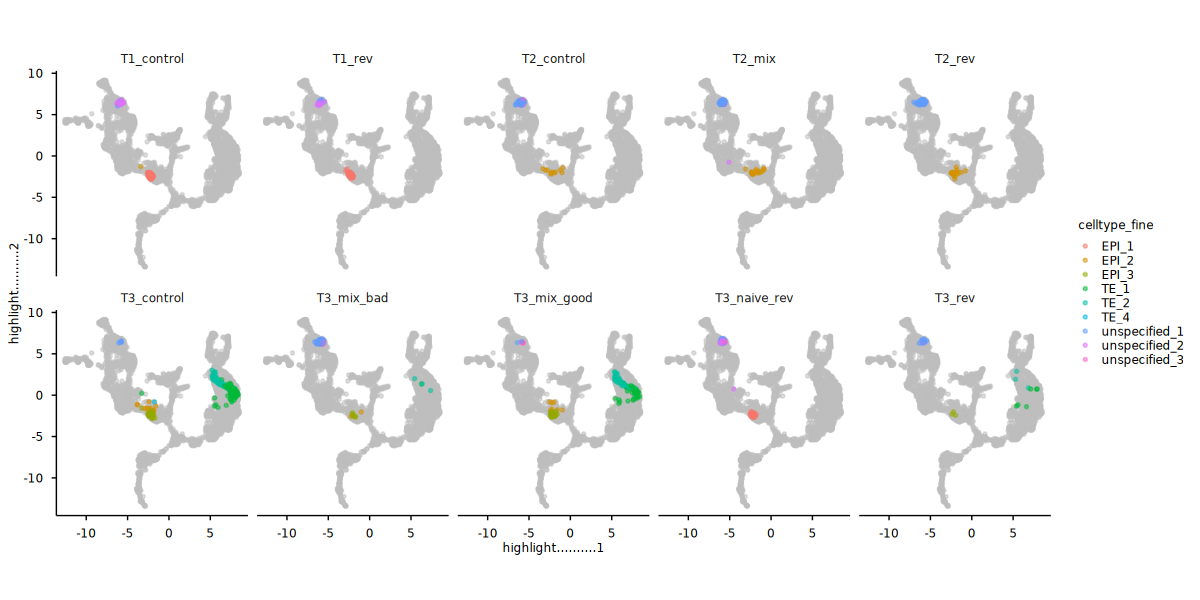

In [25]:
title = "UMAP_celltype_fine"

w <- 10
h <- 5
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = celltype_fine)) + 
    geom_point(size = 0.5, alpha = 0.5)+
    settheme+
    theme(axis.text.x = element_text(angle = 0))+
  coord_fixed(ratio = 1) +
  gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
 facet_wrap(~ sample, nrow =2)
  #scale_color_manual(values=celltype_col)


ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

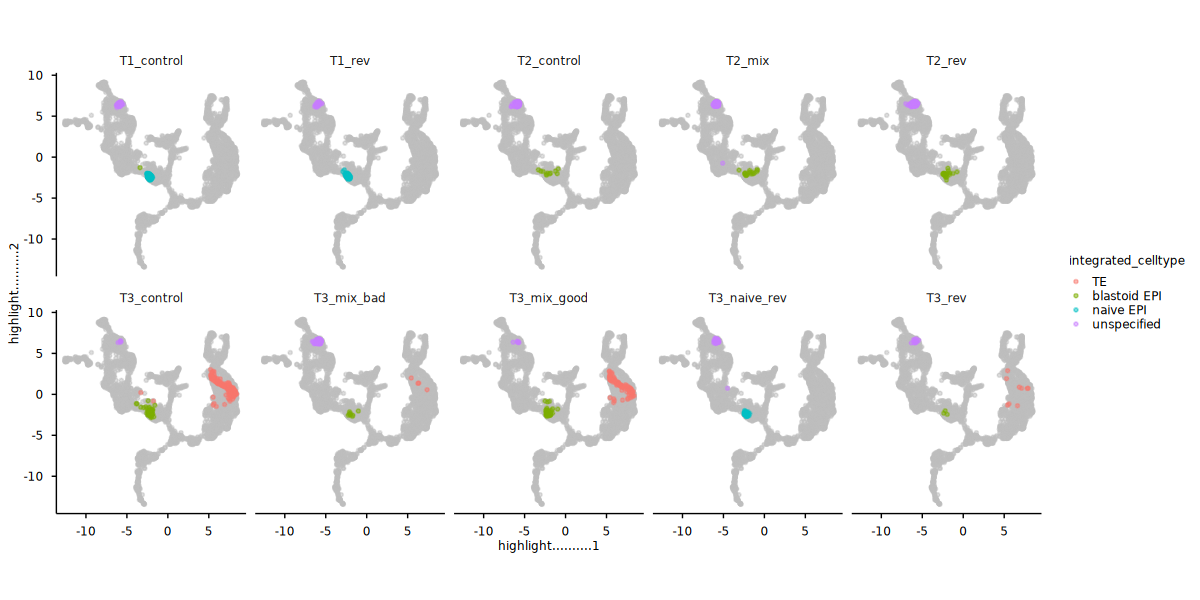

In [26]:
title = "UMAP_manual_celltype"

w <- 10
h <- 5
options(repr.plot.width=w, repr.plot.height=h)

#UMAPdf$highlight_group <- ifelse(UMAPdf$pj == 'query', as.character(UMAPdf$EML), "normal")
#UMAPdf_background <- UMAPdf[UMAPdf$pj !=  'query',]

UMAP = 
ggplot(df_umap, aes(x=UMAP_1, y=UMAP_2, color = integrated_celltype)) + 
    geom_point(size = 0.5, alpha = 0.5)+
    settheme+
    theme(axis.text.x = element_text(angle = 0))+
  coord_fixed(ratio = 1) +
  gghighlight(pj == 'query', use_direct_label = FALSE, use_group_by = FALSE)+
 facet_wrap(~ sample, nrow =2)
  #scale_color_manual(values=celltype_col)


ggsave(plot = UMAP, filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h = h)

UMAP

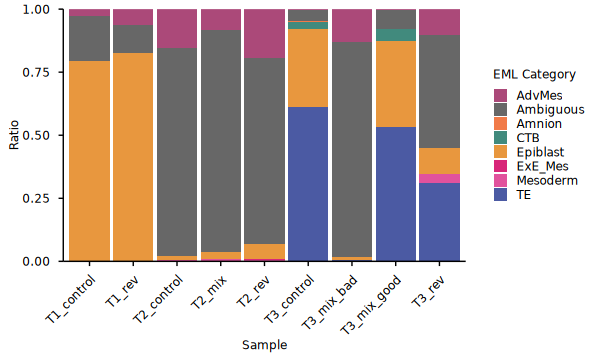

In [27]:
# Compute the ratio of each EML category per sample
df_ratio <- df_umap %>%
  #filter(EML.y != NA)%>%
  group_by(sample, pred_EML) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(ratio = count / sum(count))%>%
  filter(!grepl("Other",sample, ignore.case = TRUE)) %>%
  filter(!sample == "T3_naive_rev") 

title = "celltype_ratio"

w <- 5
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

#sample_order <- c('T1_control','T1_rev','T2_control','T2_mix','T2_rev','T3_control','T3_mix_good','T3_rev','T3_mix_bad','T3_naive_rev') 

# Plot the ratio as a bar chart
bar_ratio = ggplot(df_ratio, aes(x = sample, y = ratio, fill = pred_EML)) +
  geom_bar(stat = "identity", position = "stack") +  # Stacked bars for proportion
  labs(
       x = "Sample",
       y = "Ratio",
       fill = "EML Category") +
  settheme +
  scale_fill_manual(values=celltype_col)+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))



ggsave(plot = bar_ratio , filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h =h)

bar_ratio 

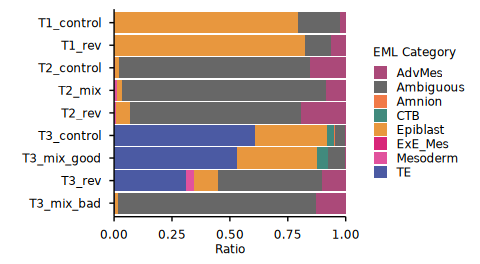

In [28]:
# Compute the ratio of each EML category per sample
df_ratio <- df_umap %>%
  #filter(EML.y != NA)%>%
  group_by(sample, pred_EML) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(ratio = count / sum(count))%>%
  filter(!grepl("Other",sample, ignore.case = TRUE))

title = "celltype_ratio"

w <- 4
h <- 2.2
options(repr.plot.width=w, repr.plot.height=h)

sample_order <- c('T1_control','T1_rev','T2_control','T2_mix','T2_rev','T3_control','T3_mix_good','T3_rev','T3_mix_bad','T3_naive_rev') 

# Plot the ratio as a bar chart
bar_ratio = ggplot(df_ratio%>% subset(!sample %in% c(NA, 'T3_naive_rev'))%>%
  mutate(sample = factor(sample, levels = (sample_order))), aes(x = sample, y = ratio, fill = pred_EML)) +
  geom_bar(stat = "identity", position = "stack") +  # Stacked bars for proportion
  labs(
       x = "",
       y = "Ratio",
       fill = "EML Category") +
    coord_flip()+
  settheme +
  scale_fill_manual(values=celltype_col)+
  #theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  scale_x_discrete(limits = rev)



ggsave(plot = bar_ratio , filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h =h)

bar_ratio 

In [30]:
head(df_ratio)

sample,pred_EML,count,ratio
<chr>,<chr>,<int>,<dbl>
T1_control,AdvMes,13,0.02850877
T1_control,Ambiguous,82,0.17982456
T1_control,Epiblast,361,0.79166667
T1_rev,AdvMes,11,0.06508876
T1_rev,Ambiguous,19,0.11242604
T1_rev,Epiblast,139,0.82248521


In [34]:
unique(df_ratio$pred_EML)

[1] "off-target(post-implantation)" "Unspecified"                  
[3] "Epiblast"                      "Trophoblast"                  
[5] NA

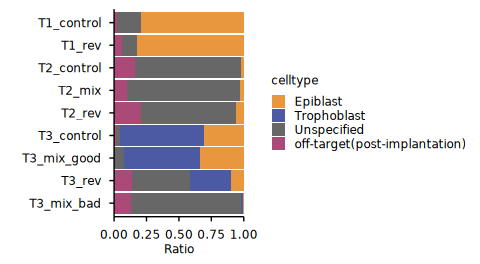

In [38]:
# Compute the ratio of each EML category per sample
df_ratio <- df_umap %>%
  #filter(EML.y != NA)%>%
  group_by(sample, pred_EML) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(ratio = count / sum(count))%>%
  filter(!grepl("Other",sample, ignore.case = TRUE))

df_ratio <- df_ratio %>%
  mutate(
    celltype = case_when(
      pred_EML %in% c("AdvMes", "Mesoderm", "ExE_Mes", "Amnion") ~ "off-target(post-implantation)",
      pred_EML %in% c("CTB", "TE") ~ "Trophoblast",
      pred_EML == "Ambiguous" ~ "Unspecified",
      TRUE ~ pred_EML
    ),
    celltype = factor(
      celltype,
      levels = c(
        "EPI",
        "Trophoblast",
        "off-target(post-implantation)",
        "Unspecified"
      )
    )
  )
  )


title = "celltype_ratio"

w <- 4
h <- 2.2
options(repr.plot.width=w, repr.plot.height=h)

sample_order <- c('T1_control','T1_rev','T2_control','T2_mix','T2_rev','T3_control','T3_mix_good','T3_rev','T3_mix_bad','T3_naive_rev') 

# Plot the ratio as a bar chart
bar_ratio = ggplot(df_ratio%>% subset(!sample %in% c(NA, 'T3_naive_rev'))%>%
  mutate(sample = factor(sample, levels = (sample_order))), aes(x = sample, y = ratio, fill = celltype)) +
  geom_bar(stat = "identity", position = "stack") +  # Stacked bars for proportion
  labs(
       x = "",
       y = "Ratio",
       fill = "celltype") +
    coord_flip()+
  settheme +
  scale_fill_manual(values=celltype_col)+
  #theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  scale_x_discrete(limits = rev)



ggsave(plot = bar_ratio , filename = sprintf("%s/%s.pdf",out_dir, title), w = w, h =h)

bar_ratio 